This file can be used to plot the Fourier spectrum before and after a nonlinearity is applied.

In [2]:
import matplotlib.pyplot as plt 
import numpy as np

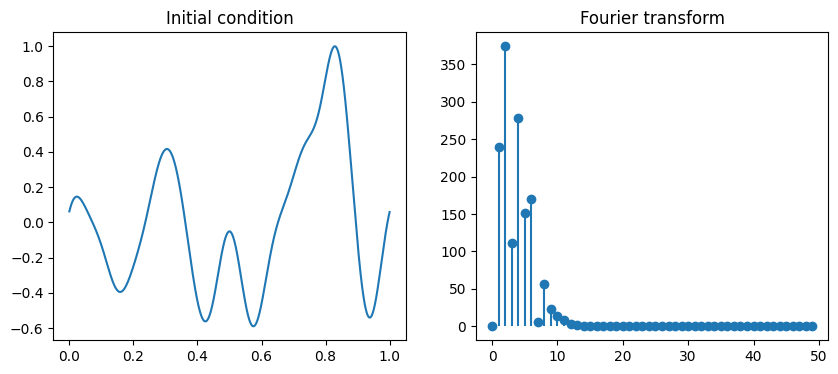

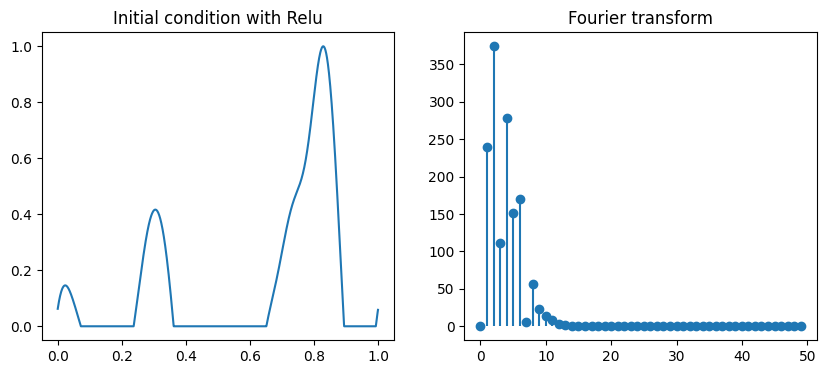

In [34]:
init_modes = 16
res = 2048

def random_initial_condition(N_x, kmax):
    """Create smooth random initial condition via truncated Fourier series."""
    coeffs = np.zeros(N_x, dtype=np.complex128)
    # Add some random low-frequency content
    coeffs[1:kmax] = (np.random.randn(kmax-1) + 1j*np.random.randn(kmax-1)) * np.exp(-0.5*(np.arange(1,kmax)/(kmax/4))**2)
    coeffs[-kmax+1:] = np.conj(np.flip(coeffs[1:kmax]))
    u = np.real(np.fft.ifft(coeffs))
    # Normalize amplitude
    u = u / np.max(np.abs(u))
    return u

def relu(x):
    return x * bool( x > 0)


x = np.linspace(0, 1, res)
y = random_initial_condition(res, init_modes)

y_ft = np.fft.fft(y)

fig, ax = plt.subplots(1,2, figsize = (10,4))

ax[0].plot(x,y)
ax[0].set_title("Initial condition")
ax[1].stem(np.arange(50), np.abs(y_ft[:50]), basefmt=" ")
ax[1].set_title("Fourier transform")
ax[1].plot(5)

y_relu = [relu(i) for i in y]
y_relu_ft = np.fft.fft(y_relu)

fig, bx = plt.subplots(1,2, figsize = (10,4))
bx[0].plot(x, y_relu)
bx[0].set_title("Initial condition with Relu")
bx[1].stem(np.arange(50), np.abs(y_ft[:50]), basefmt=" ")
bx[1].set_title("Fourier transform")
plt.show()

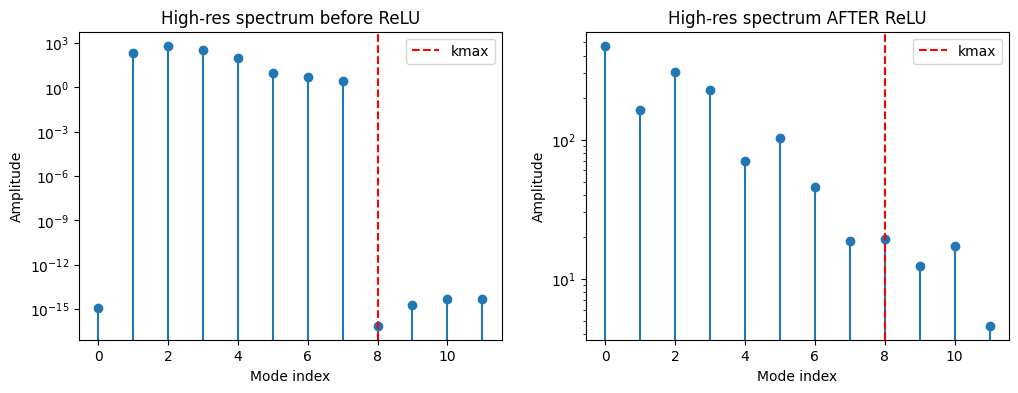

In [16]:
import numpy as np
import matplotlib.pyplot as plt

N_hi = 2048
kmax = 8
plot_lim = int(1.5*kmax)

def random_initial_condition(N_x, kmax):
    coeffs = np.zeros(N_x, dtype=np.complex128)
    # random low-frequency content
    k = np.arange(1, kmax)
    coeffs[1:kmax] = (np.random.randn(kmax-1) + 1j*np.random.randn(kmax-1)) \
                     * np.exp(-0.5*(k/(kmax/4))**2)
    coeffs[-kmax+1:] = np.conj(np.flip(coeffs[1:kmax]))
    u = np.fft.ifft(coeffs)
    u = np.real(u)
    u /= np.max(np.abs(u))
    return u

def relu(x):
    return np.maximum(x, 0.0)

# ---------- high-res setup ----------


x_hi = np.linspace(0, 1, N_hi, endpoint=False)
u_hi = random_initial_condition(N_hi, kmax)

U_hi = np.fft.fft(u_hi)

u_relu_hi = relu(u_hi)
U_relu_hi = np.fft.fft(u_relu_hi)

# plot spectra before/after ReLU (only first, say, 256 modes)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(np.arange(0,plot_lim), np.abs(U_hi[:plot_lim]), basefmt=" ")
plt.axvline(x = kmax, color = "r", linestyle = "dashed", label = "kmax")
plt.title("High-res spectrum before ReLU")
plt.xlabel("Mode index")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.legend()

plt.subplot(1,2,2)
plt.stem(np.arange(0,plot_lim), np.abs(U_relu_hi[:plot_lim]), basefmt=" ")
plt.axvline(x = kmax, color = "r", linestyle = "dashed", label = "kmax")
plt.xlabel("Mode index")
plt.ylabel("Amplitude")
plt.title("High-res spectrum AFTER ReLU")
plt.yscale("log")
plt.legend()
plt.show()


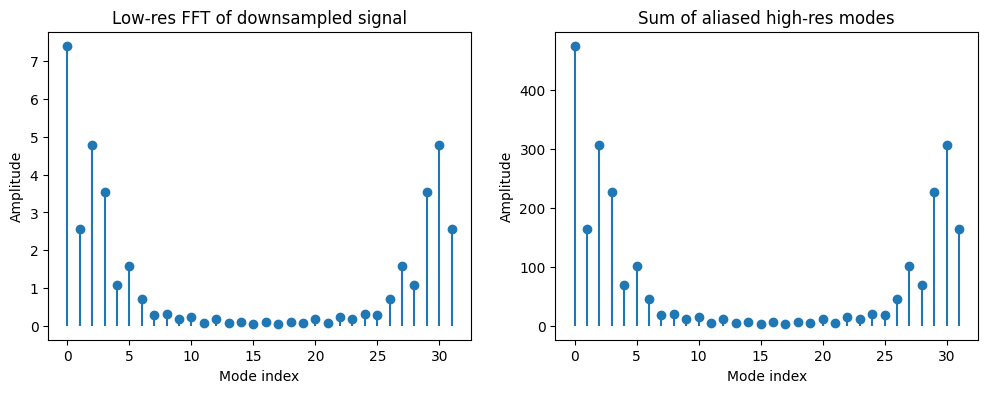

In [17]:
# ---------- downsample and show aliasing ----------
N_lo = 32
step = N_hi // N_lo
u_relu_lo = u_relu_hi[::step]               # pick every 'step'-th sample
U_relu_lo = np.fft.fft(u_relu_lo)

# Compare low-res FFT to aliased sum of high-res FFT
k_vals = np.arange(N_lo)
U_alias_from_hi = np.zeros(N_lo, dtype=np.complex128)
for k in k_vals:
    # collect all high-res indices that alias to this low-res k
    idxs = np.arange(k, N_hi, N_lo)
    U_alias_from_hi[k] = U_relu_hi[idxs].sum()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(k_vals, np.abs(U_relu_lo), basefmt=" ")
plt.title("Low-res FFT of downsampled signal")
plt.xlabel("Mode index")
plt.ylabel("Amplitude")

plt.subplot(1,2,2)
plt.stem(k_vals, np.abs(U_alias_from_hi), basefmt=" ")
plt.title("Sum of aliased high-res modes")
plt.xlabel("Mode index")
plt.ylabel("Amplitude")
plt.show()
    